# Credit Card Fraud Detection using ANN

**Goal:** Build an Artificial Neural Network (ANN) trained with backpropagation and gradient descent optimization to detect fraudulent credit card transactions.

**Key Challenge:** The dataset is highly imbalanced — fraud transactions make up less than 1% of all transactions. We use class weights to handle this imbalance natively inside the ANN.

**Hyperparameter Tuning:** Grid Search with Cross Validation is used to find the best combination of hidden layer sizes and learning rate.

### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    auc,
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

### Step 2: Load the Dataset

In [2]:
df = pd.read_csv("data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
print("Class distribution:")
print(df["Class"].value_counts())
print(f"\nFraud percentage: {df['Class'].mean() * 100:.4f}%")

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


Key columns:
- **V1–V28:** PCA-transformed features
- **Time:** seconds elapsed between each transaction and the first transaction
- **Amount:** transaction amount
- **Class:** target variable — 0 = normal, 1 = fraud

### Step 3: Split Features and Target

In [5]:
X = df.drop("Class", axis=1)  # input features
y = df["Class"]               # target label (0 = normal, 1 = fraud)

### Step 4: Scale the Data

V1–V28 are already PCA-transformed. We only scale `Time` and `Amount`.

In [6]:
scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])
X["Time"]   = scaler.fit_transform(X[["Time"]])

# Verify scaling worked
print("Scaling complete!")
print(f"Amount - Mean: {X['Amount'].mean():.4f}, Std: {X['Amount'].std():.4f}")
print(f"Time - Mean: {X['Time'].mean():.4f}, Std: {X['Time'].std():.4f}")

Scaling complete!
Amount - Mean: 0.0000, Std: 1.0000
Time - Mean: -0.0000, Std: 1.0000


### Step 5: Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)

Training set size: (227845, 30)
Test set size:     (56962, 30)


### Step 6: Handle Class Imbalance with Class Weights

Instead of SMOTE, the ANN handles class imbalance by assigning higher weights to the minority class (fraud) during training. This penalizes the model more for missing a fraud case, which is the correct approach for neural networks.

In [8]:
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}

print(f"Class weights: {class_weight_dict}")
print(f"Fraud is weighted {weights[1]:.1f}x more than normal transactions")

Class weights: {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}
Fraud is weighted 289.1x more than normal transactions


### Step 7: Grid Search + Cross Validation for Hyperparameter Tuning

Grid Search tests every combination of hyperparameters and uses Stratified K-Fold Cross Validation to find the best settings. We search over:
- **hidden_layer_sizes:** the number of neurons in each hidden layer
- **learning_rate_init:** the step size for gradient descent optimization

The ANN is trained using **backpropagation** with the **Adam optimizer** (adaptive gradient descent).

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Pipeline ensures data is scaled before entering the ANN
# This prevents the overflow error
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        solver="adam",
        activation="relu",
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

param_grid = {
    "mlp__hidden_layer_sizes": [(64,), (32, 16)],
    "mlp__learning_rate_init": [0.0001, 0.001]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Running Grid Search...")
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV AUPRC: {grid_search.best_score_:.4f}")

ann_model = grid_search.best_estimator_
print("Model training complete.")

Running Grid Search...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/Users/ginalopez/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ginalopez/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ginalopez/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ginalopez/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ginalopez/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ginalopez/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: Runtim


Best parameters: {'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.001}
Best CV AUPRC: 0.8102
Model training complete.


### Step 8: Train Final ANN with Best Hyperparameters

Using the best parameters found by Grid Search, we retrain the ANN on the full training set.

In [10]:
# Skip this cell — ann_model is already trained in Step 7
# The best model from Grid Search is stored in grid_search.best_estimator_
print("ann_model is already set from Step 7. Continue to Step 9 for predictions.")

ann_model is already set from Step 7. Continue to Step 9 for predictions.


### Step 9: Make Predictions

In [11]:
# Predicted class labels
y_pred = ann_model.predict(X_test)

# Predicted probabilities for fraud class (used for AUPRC and ROC)
y_scores = ann_model.predict_proba(X_test)[:, 1]

/Users/ginalopez/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ginalopez/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ginalopez/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ginalopez/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ginalopez/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ginalopez/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: Runtim

### Step 10: Evaluation

#### Classification Report

In [12]:
print(classification_report(y_test, y_pred, target_names=["Normal", "Fraud"]))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



#### Confusion Matrix

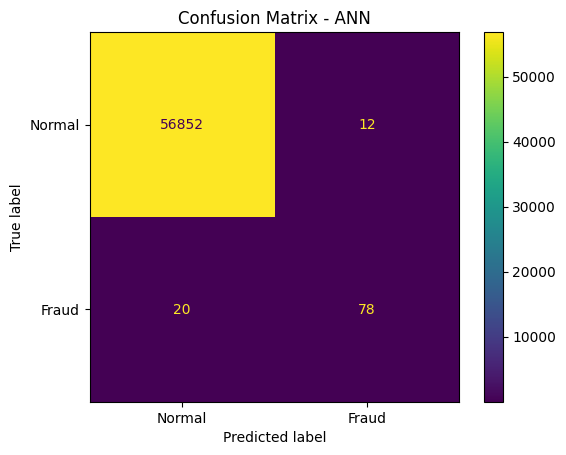

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraud"])
disp.plot()
plt.title("Confusion Matrix - ANN")
plt.show()

#### Precision-Recall Curve and AUPRC

AUPRC:                   0.8543
Average Precision Score: 0.8545


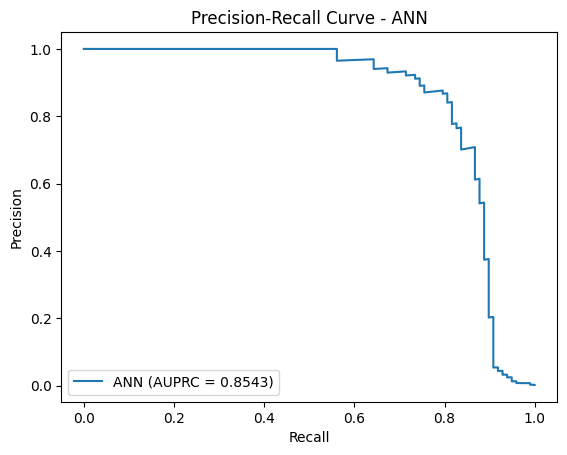

In [14]:
precision, recall, _ = precision_recall_curve(y_test, y_scores)
pr_auc = auc(recall, precision)
avg_precision = average_precision_score(y_test, y_scores)

print(f"AUPRC:                   {pr_auc:.4f}")
print(f"Average Precision Score: {avg_precision:.4f}")

plt.figure()
plt.plot(recall, precision, label=f"ANN (AUPRC = {pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - ANN")
plt.legend()
plt.show()

#### ROC Curve and AUC

ROC-AUC: 0.9812


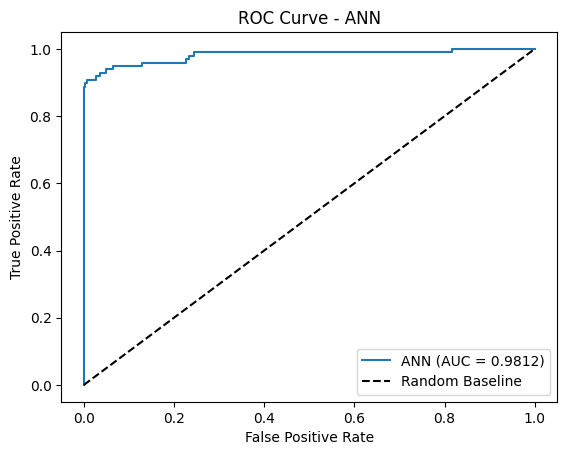

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

print(f"ROC-AUC: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f"ANN (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN")
plt.legend()
plt.show()

#### Final Metrics Summary

In [16]:
p  = precision_score(y_test, y_pred)
r  = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 40)
print("ANN Final Metrics Summary")
print("=" * 40)
print(f"Precision:  {p:.4f}")
print(f"Recall:     {r:.4f}")
print(f"F1-Score:   {f1:.4f}")
print(f"AUPRC:      {pr_auc:.4f}")
print(f"ROC-AUC:    {roc_auc:.4f}")
print("=" * 40)

ANN Final Metrics Summary
Precision:  0.8667
Recall:     0.7959
F1-Score:   0.8298
AUPRC:      0.8543
ROC-AUC:    0.9812


In [17]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_scores)
print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9812


### Conclusion for ANN

The Artificial Neural Network was trained using backpropagation with Adam optimizer (adaptive gradient descent). Grid Search with Stratified 3-Fold Cross Validation was used to find the best hyperparameters (hidden layer sizes and learning rate). Class weights were applied to handle the class imbalance natively without synthetic data generation. The model was evaluated using Precision, Recall, F1-Score, AUPRC, and ROC-AUC.